In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import datetime as dt

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve

from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score

from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve


In [ ]:
pip install kagglehub

# Load data

## NROWS = 500 000

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 500_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/tmp/ipykernel_6220/2448335001.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [ ]:
df = df.drop_duplicates()

# Filter on most visited categories
## Output Data Frame: df_elec

In [19]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone',
'electronics.clocks',
'computers.notebook',
'electronics.video.tv'
]


In [20]:
df_elec=df[df['category_code'].isin(list_category_code)]

# Feature computing
## Sequence of events per user_id, user_session, category_id
## Duration between session start and end of the session

In [22]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_6220/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_6220/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [133]:
#event sequence and duration mean per user id, user session
df_events = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : max(x) - min(x))
}).reset_index()

## The last event of a given sequence is the target
### For the 'one event' sequence missing is replaced by 'one_view'

In [134]:
df_events['seq_list'] = df_events['event_type_str'].apply(str.split)
df_events['seq_list_1'] = df_events['seq_list'].apply(lambda x : x[:-1])
df_events['target'] = df_events['seq_list'].apply(lambda x : x[-1])
df_events ['seq_one'] = df_events['seq_list_1'].apply(lambda x : ['one_view'] if x==[] else x)
df_events['seq'] = df_events.agg({'seq_one' : " ".join })




#df_events['seq_1'] = df_events.groupby(['user_id', 'user_session'])['seq_list'].apply(lambda x: x[:-1])

#df_events_time['target'] = df_events.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: x[-1])

/tmp/ipykernel_6220/3806566200.py:5: FutureWarning: using <built-in method join of str object at 0x7656ea3affb0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df_events['seq'] = df_events.agg({'seq_one' : " ".join })


## Sequence length and duration_mean

In [140]:
df_events = df_events.rename(columns={'event_time':'duration'})

### Sequence Length -> sequence_len

In [ ]:
df_events['sequence_len'] = df_events['seq'].apply(lambda x : len(x.split()))

### Duration mean -> duration_mean_sec

In [ ]:
df_events['duration_mean']=df_events['duration']/df_events['sequence_len']
df_events['duration_mean_sec'] = df_events['duration_mean'].dt.total_seconds()

# X and y

## Target definition

In [137]:
df_events['target_0_1'] = df_events['target'].apply(lambda x : 1 if x=='purchase' else 0)

In [ ]:
y = df_events['target_0_1']


## X definition

In [ ]:
X = df_events.loc[:,['category_id', 'seq','duration_mean_sec', 'sequence_len']]

# Train-test split 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

# Preprocessing

## Categorical variable encoding : category_id & seq

### Encoding Categorical features OneHot

In [ ]:
pipe_cat = Pipeline([('ohe',OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas"))])


### Scaling numerical features RobustScaler

In [ ]:
pipe_num = Pipeline([('rb_scale', RobustScaler().set_output(transform="pandas"))])

In [208]:
encoder = OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas")

X_train_encoder = encoder.fit_transform(X_train[['seq', 'category_id']])
X_test_encoder = encoder.transform(X_test[['seq', 'category_id']])


### Encoding and Scaling in a Column Transformer

In [ ]:
col_transf = ColumnTransformer([
    ('cat_transform',pipe_cat, ["category_id", "seq", "nb_product"]),
    ('num_transform', pipe_num, ['sequence_len', 'duration_mean_sec'])
])

# Baseline model Logistic Regression 

In [ ]:
pipe = Pipeline([
    ("preprocessing", col_transf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
model = pipe.fit(X_train, y_train)

In [ ]:
cv_result = cross_validate(pipe, X_train, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

### Cross_validation results

In [ ]:
cv_result['test_precision'].mean()

In [ ]:
cv_result['test_recall'].mean()

In [ ]:
cv_result['test_f1'].mean()

## Precision Recall Curve

### Scoring average_precision

In [ ]:
cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/uti

In [ ]:
y_pred_prob = pipe.predict_proba(X_test)


In [245]:
y_pred_prob= y_pred_prob[:,1]

In [246]:
precision, recall, _= precision_recall_curve(y_test, y_pred_prob)

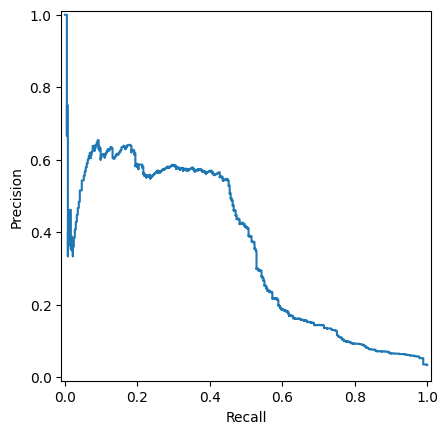

In [ ]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

### Average precision

In [248]:
cross_v_result

np.float64(0.3634476473578629)

## Calibration

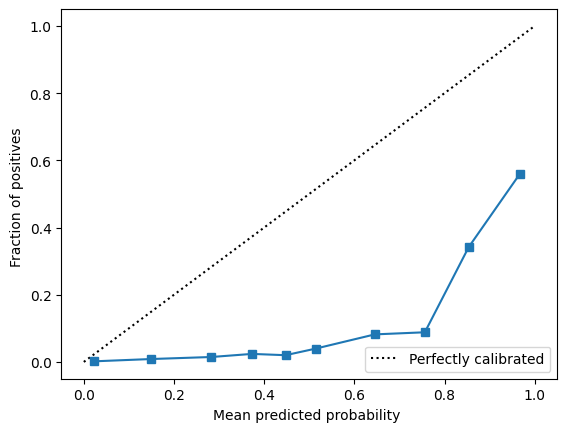

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [ ]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/u

,estimator,LogisticRegre...max_iter=1000)
,method,'sigmoid'
,cv,StratifiedKFo...shuffle=False)
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [ ]:
y_pred_prob = calibrated_clf.predict_proba(X_test)


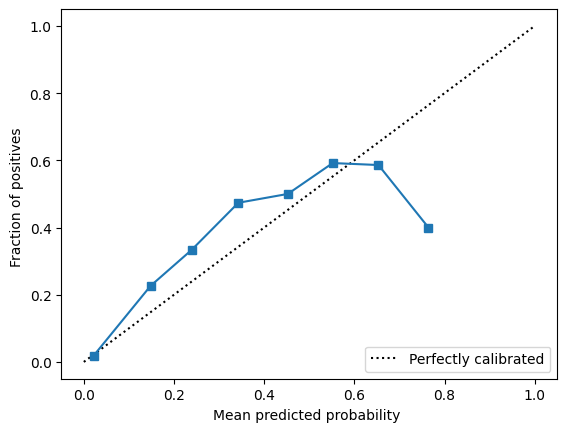

In [258]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

## Learning Curves

In [ ]:
train_sizes = [7500, 10000,15000, 20000, 25000, 30000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe, X=X_train, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/uti

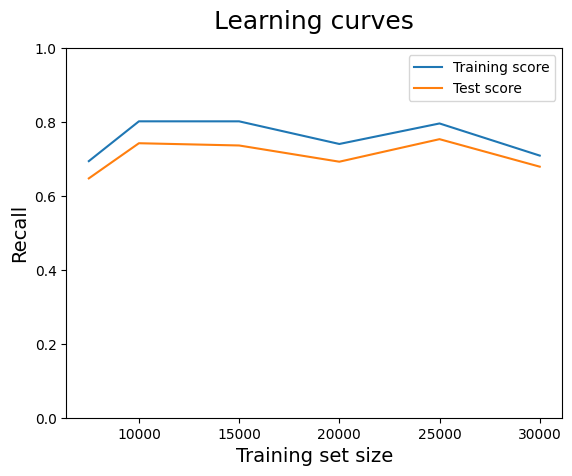

In [ ]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()